In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2
import torch
import torch.nn.functional as F

from scipy.ndimage import gaussian_filter
from scipy.signal import correlate2d, convolve2d, tukey
from scipy.interpolate import RegularGridInterpolator

from orthnet import Legendre

# Replacing CWS current algortihm with flow plus Forward Modeling of Speckle formation

# Forward Operator: |FMFTu|^2

* Reference plus object speckles; phase retrieval using flow and forward operator
* using memory effect as a regularizer?

Steps:
* Create a T matrix for a random phase pattern. Using random phase screen modeling.
* Make well defined object waves. Local curvatures.
* Optimize

To try:
1. Run flow on measurements to recover \phi_true
2. ~~Combining the data term and regularization on phase terms with optical flow~~

In [30]:
# set system params

# Grid and propagation parameters setup
wl = 640e-9 # meters
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 2000 # nx == ny

padding = 512
dist = 3e-3 # distance bw phase mask and image plane 

(3024,) float64 20 100


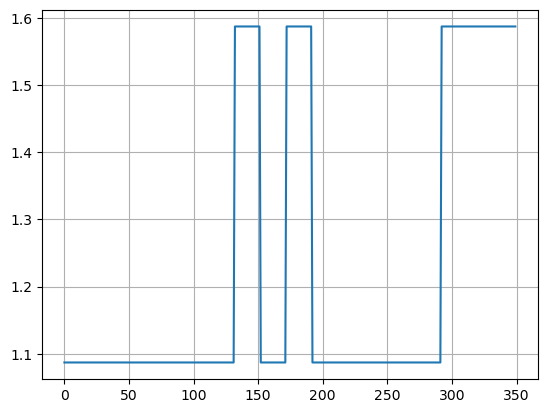

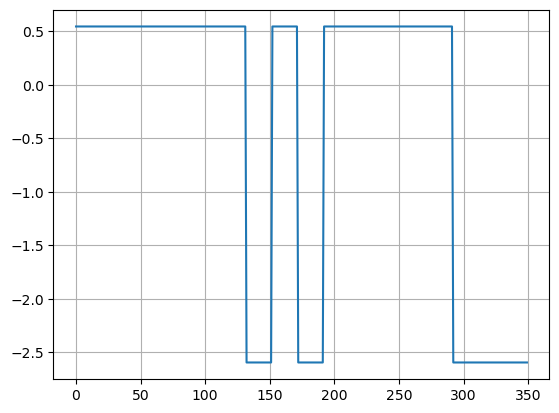

(torch.Size([3024, 3024]),
 <function Tensor.type>,
 tensor([[0.8544+0.5196j, 0.0000+0.0000j, 0.0000+0.0000j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.8544+0.5196j, 0.0000+0.0000j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.0000+0.0000j, 0.8544+0.5196j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.0000+0.0000j, 0.0000+0.0000j, 0.8544+0.5196j]],
        dtype=torch.complex128))

In [31]:
# create phase mask: 
# diagonal phase-only transmission matrix

side_length = 10e-6
tile_size = int(side_length/dx)
RI_pm = 1.46
height = wl/(2*(RI_pm - n_0))#695e-9 # \pi = 2\pi /wl * (RI_pm - 1)*h => h = wl/(2*(RI_pm - n_0))
prob = 0.5

nx_tiles = nx//tile_size
samples_mask = np.random.uniform(size=nx_tiles) > prob

# strucutres size-distance away from boundary
samples_mask[0] = 0.
samples_mask[-1] = 0.

h_map_pm = height*np.repeat(samples_mask, tile_size, axis=0)
h_map_pm = np.pad(h_map_pm, padding, 'edge')

opd_pm = h_map_pm*RI_pm + (h_map_pm.max() - h_map_pm)*n_0
t_diag = np.exp(1j*(2*np.pi/wl)*opd_pm) # no negative sign

print(h_map_pm.shape, h_map_pm.dtype, tile_size, nx_tiles)

plt.plot(opd_pm[500:850]/wl)
plt.grid()
plt.show()

plt.plot(np.angle(t_diag[500:850]))
plt.grid()
plt.show()

T_d = torch.diag(torch.from_numpy(t_diag))
T_d.shape, T_d.type, T_d[:4, :4]


torch.Size([2512, 2512]) torch.complex64 tensor([[-1.0000-0.0005j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j],
        [ 0.0000+0.0000j, -1.0000+0.0034j,  0.0000+0.0000j,  0.0000+0.0000j],
        [ 0.0000+0.0000j,  0.0000+0.0000j, -0.9999+0.0151j,  0.0000+0.0000j],
        [ 0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j, -0.9995+0.0327j]])


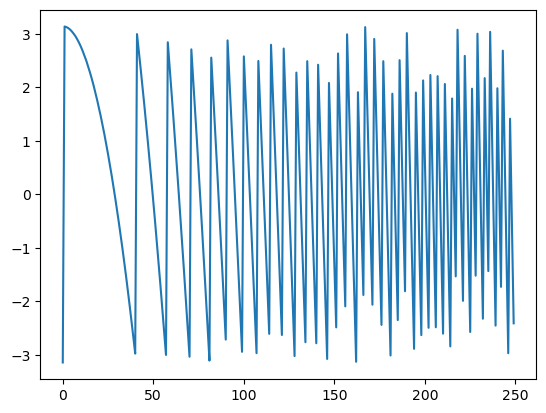

In [32]:
# create phase modulation diagnoal matrix that is a function of distance z

def prop_phase_matrix(field, dist, wl, dx):

        k0 = 2 * torch.pi / wl
        Nx = field.shape[0]

        kx = torch.fft.fftfreq(Nx, dx) * 2 * torch.pi
        kz = torch.sqrt(k0**2 - kx**2)
        
        return torch.diag(torch.exp(1j*kz*dist))

M_z = prop_phase_matrix(torch.ones(2512), dist, wl, dx)

print(M_z.shape, M_z.dtype, M_z[:4, :4])
plt.plot(torch.angle(M_z.diag())[:250])

In [33]:
# 1d propagator

def propagate_1d(field, dist, wl, dx):

        k0 = 2 * torch.pi / wl
        Nx = field.shape[0]

        kx = torch.fft.fftfreq(Nx, dx) * 2 * torch.pi
        kz = torch.sqrt(k0**2 - kx**2)

        field_fft = torch.fft.fft(field)
        transfer_function = torch.exp(1j*kz*dist)
        out_field = torch.fft.ifft(field_fft * transfer_function)
        
        return out_field

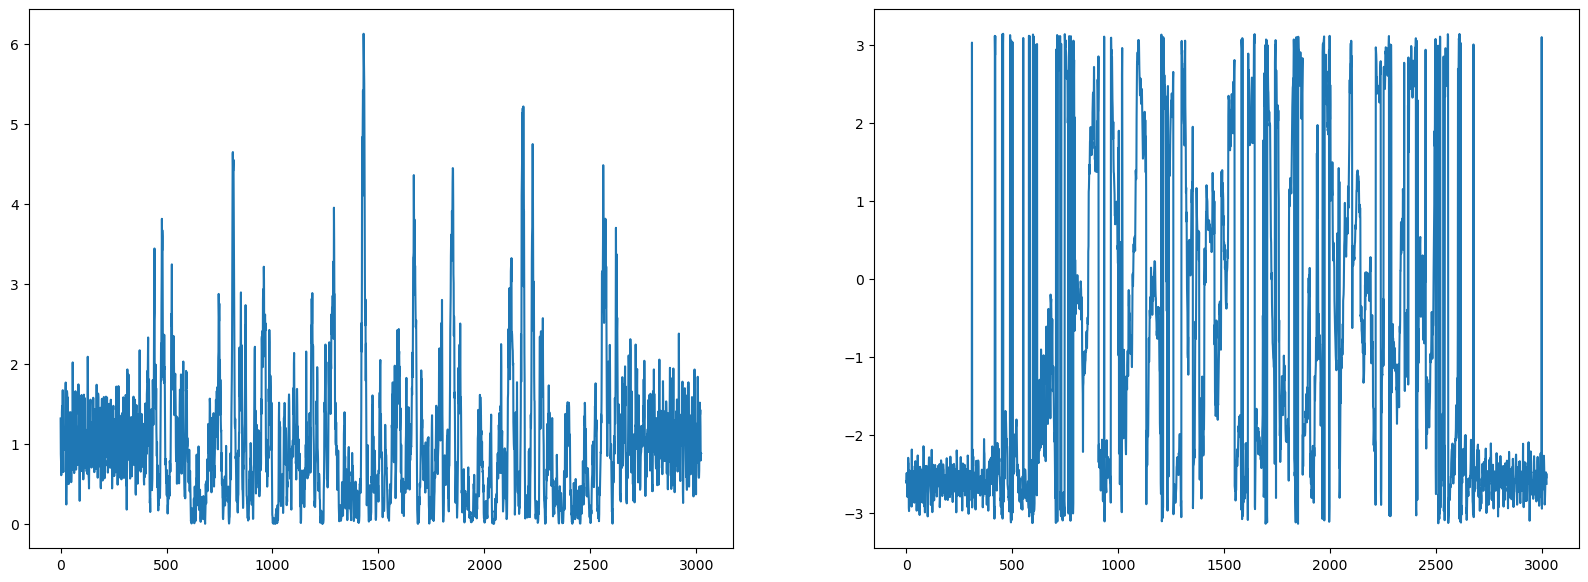

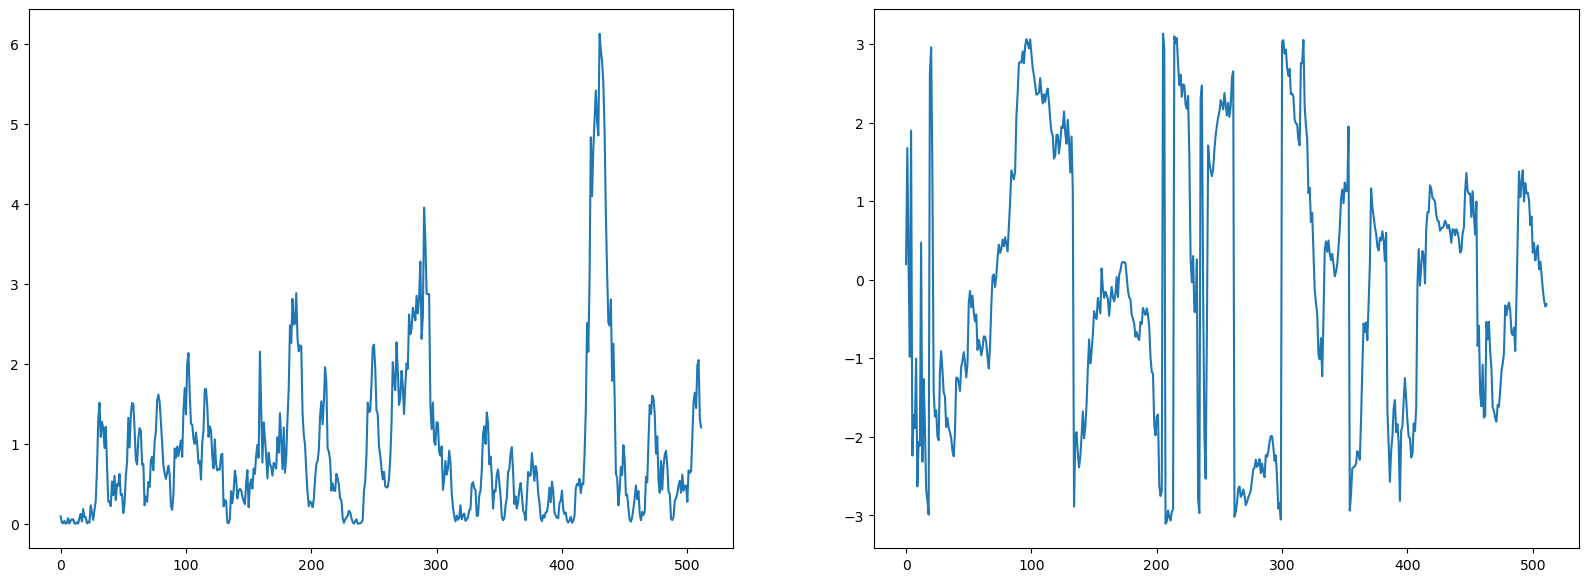

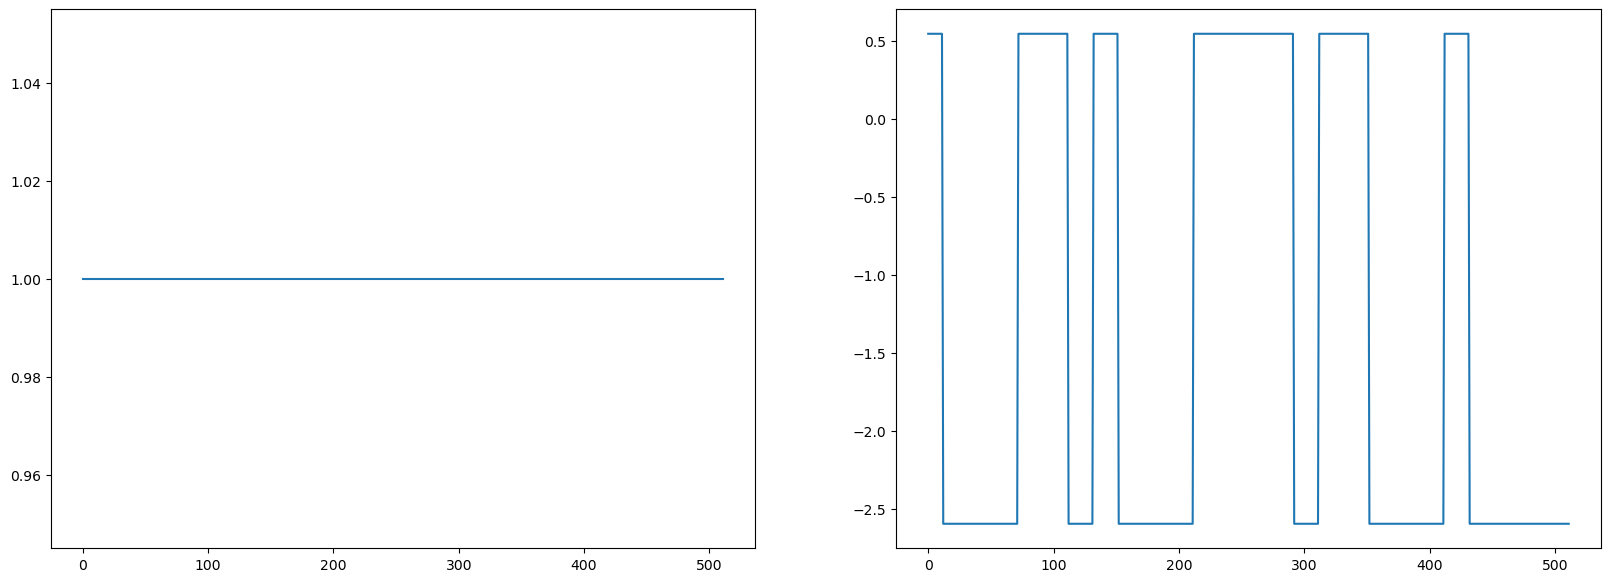

In [34]:
u_ir = propagate_1d(torch.matmul(T_d, torch.ones(T_d.shape[1], dtype=torch.complex128)), 
                    dist, wl, dx)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(np.abs(u_ir)**2)
axs[1].plot(np.angle(u_ir))

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(np.abs(u_ir[1000:1512])**2)
axs[1].plot(np.angle(u_ir[1000:1512]))

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(np.abs(t_diag[1000:1512])**2)
axs[1].plot(np.angle(t_diag[1000:1512]))

plt.show()

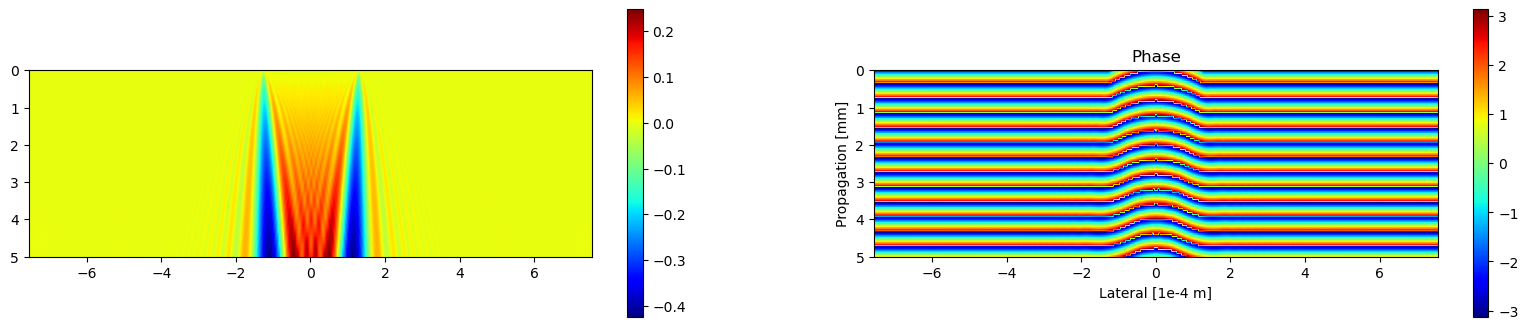

In [35]:
# converging wave
# \phi(x, y) = -k*sqrt(z_f**2 x**2 + y**2)
u_iconv_z = torch.zeros([101, u_ir.shape[0]], dtype=torch.complex128)

x_cords = torch.arange(-1*(nx/2 + padding) , nx/2 + padding)*dx
z_f = 15e-3 # m

phi_conv = torch.sqrt(z_f**2 + x_cords**2)

phi_conv[:1256] = phi_conv[1256]
phi_conv[1768:] = phi_conv[1768]

conv_field = torch.exp(-1j*(2*torch.pi/wl)*phi_conv).type(torch.complex128)

for idx, z in enumerate(np.linspace(0, 5, 101)):
    u_iconv_z[idx] = propagate_1d(conv_field, z*1e-3, wl, dx)
    # torch.matmul(T_d, conv_field)
fig, axs = plt.subplots(1, 2, figsize=(20, 4))

cm0 = axs[0].imshow(np.log10(torch.abs(u_iconv_z)**2), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm0, ax=axs[0])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Intensity')

cm1 = axs[1].imshow(torch.angle(u_iconv_z), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm1, ax=axs[1])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Phase')

plt.show()

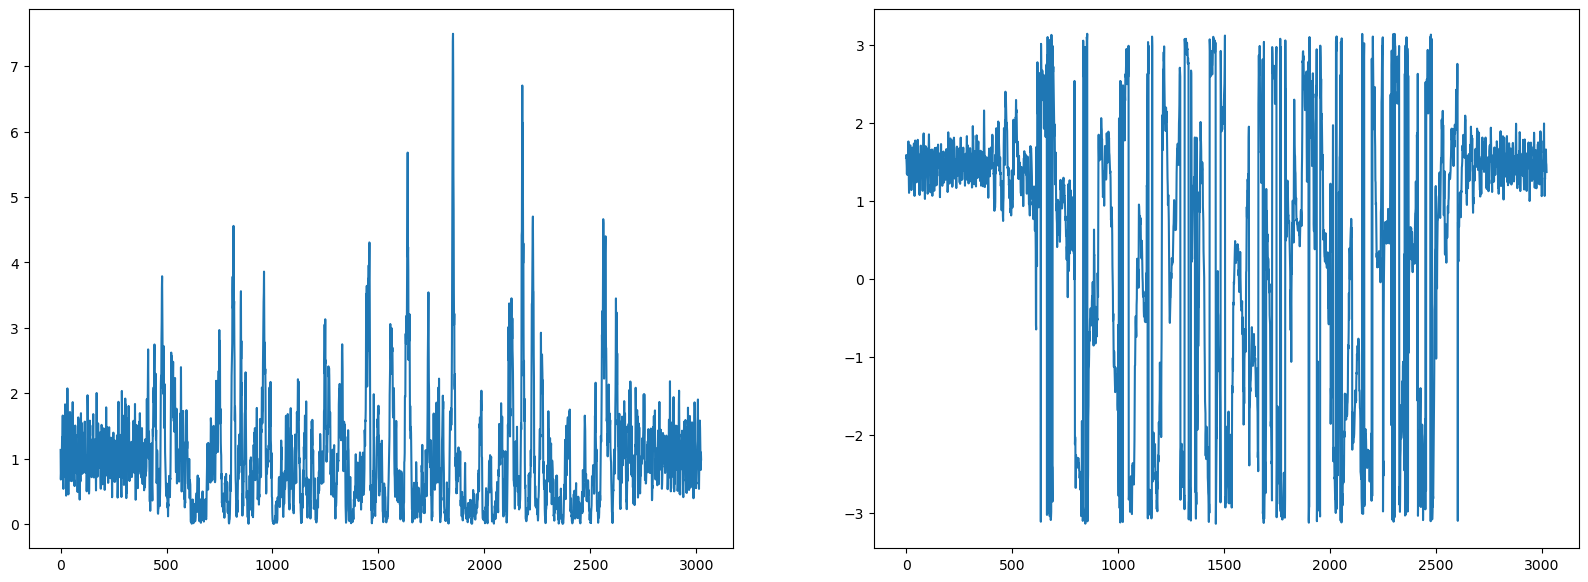

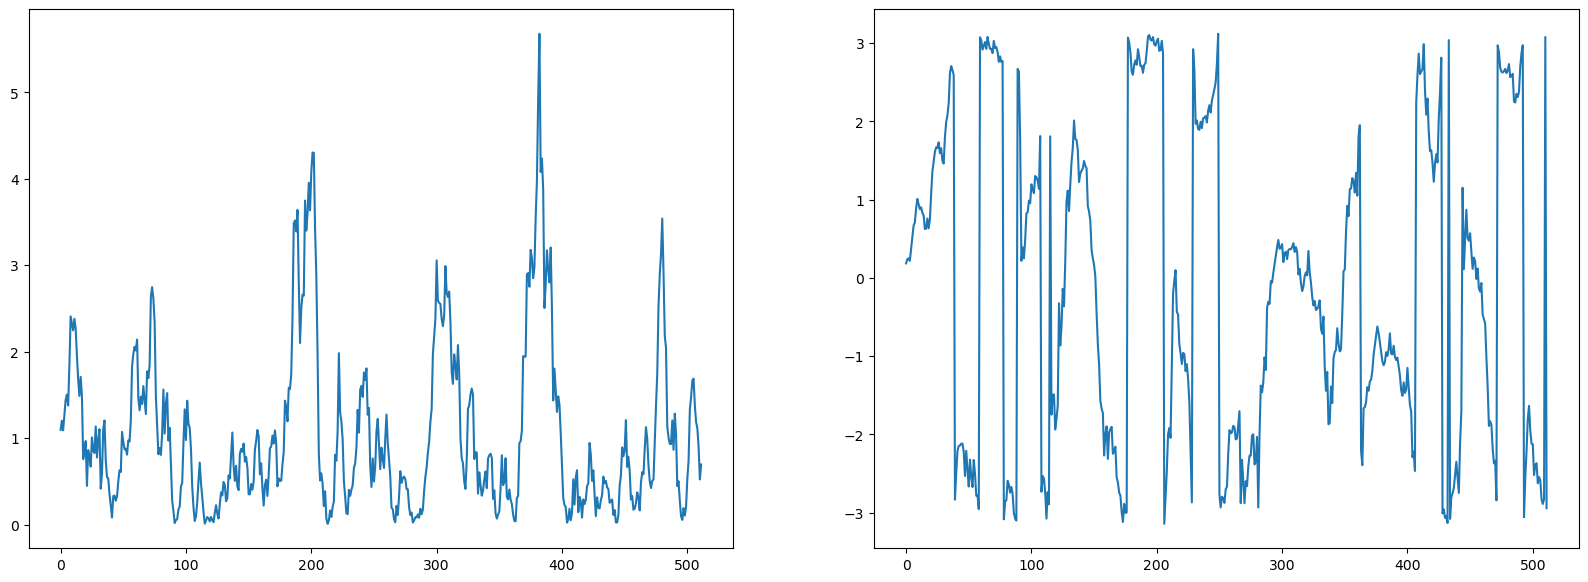

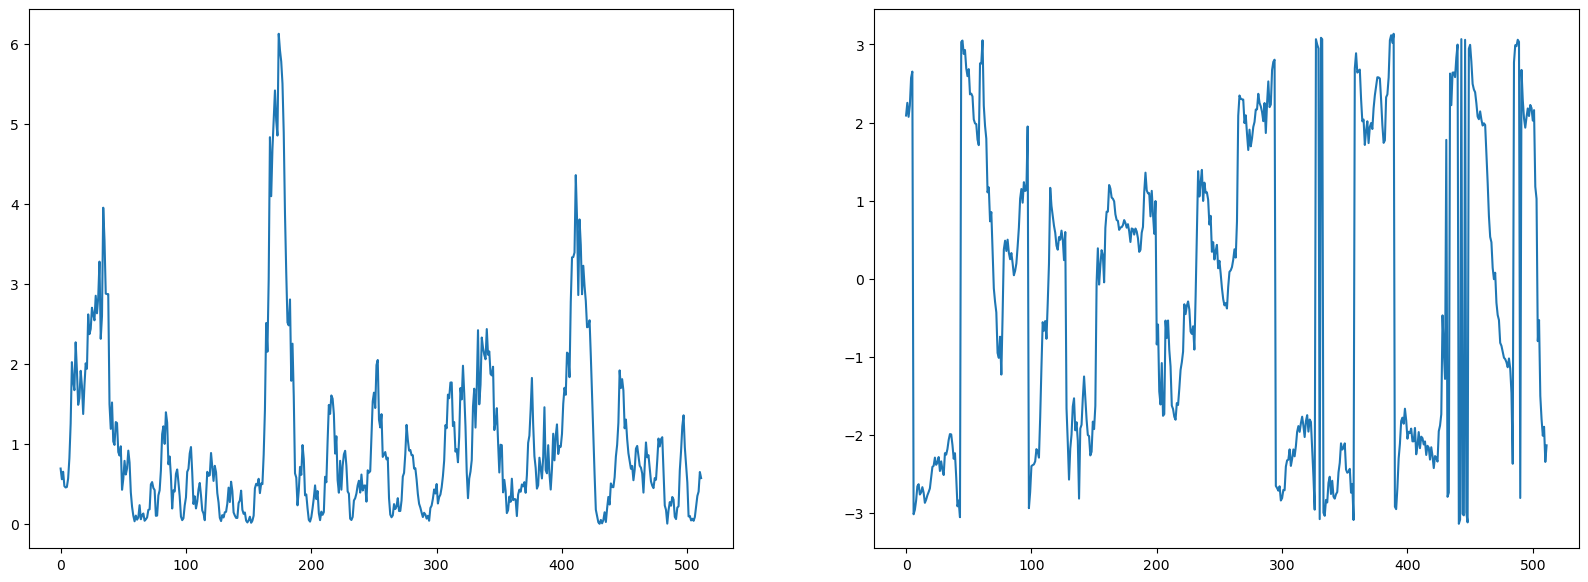

In [36]:
# converging wave
# \phi(x, y) = -k*sqrt(z_f**2 x**2 + y**2)

x_cords = torch.arange(-1*(nx/2 + padding) , nx/2 + padding)*dx
z_f = 15e-3 # m

phi_conv = torch.sqrt(z_f**2 + x_cords**2)

phi_conv[:1256] = phi_conv[1256]
phi_conv[1768:] = phi_conv[1768]

conv_field = torch.exp(-1j*(2*torch.pi/wl)*phi_conv).type(torch.complex128)

u_io = propagate_1d(torch.matmul(T_d, conv_field), dist, wl, dx)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(np.abs(u_io)**2)
axs[1].plot(np.angle(u_io))

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(np.abs(u_io[1000+256:1512+256])**2)
axs[1].plot(np.angle(u_io[1000+256:1512+256]))

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(np.abs(u_ir[1000+256:1512+256])**2)
axs[1].plot(np.angle(u_ir[1000+256:1512+256]))

plt.show()

In [20]:
def total_variation_loss(img, l=2):
     return (torch.abs(img[1:] - img[:-1])**l).sum()/img.size()[0]

# optimization5: min_{A, phi} || |FMFT Ae{i.\phi}|^2 - |u|^2 || + \beta|({a_i}_i)| + \gamma|TV (A)|

* phi = \sum_i a_i \theta_i

* I_est fits to I_mo
* phi_est fits to phi_true
    * Requires around 200 polynomials
        * larger or even around 200 oscillations
        * Smaller does not fit as well
    * Fit upto a global phase
* A_est has to be fixed to work properly

In [45]:
# optimization || |FMFT Ae{i.phi}|^2 - |u|^2 || + \beta|TV phi|

# dist = 5e-3
# z_f = 15e-3 # m
iter = 1000
learning_rate = 1e-1

I_mo = torch.abs(u_io)**2

A_est = torch.ones_like(I_mo)

num_pol = 100
gamma = 1e8

x = torch.linspace(-1, 1, x_cords.shape[0])
L = Legendre(x.unsqueeze(1), num_pol)

coeff_est = torch.randn(num_pol+1, 1)
coeff_est.requires_grad = True

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam([coeff_est], lr=learning_rate)

losses = []
losses_data = []
losses_A = []

for i in range(iter):
    u_est = A_est*torch.exp(1j*torch.matmul(L.tensor, coeff_est).squeeze())
    y = torch.abs(propagate_1d(torch.matmul(T_d, u_est), dist, wl, dx))**2
    
    loss1 = loss_fn(y, I_mo)
    loss2 = gamma*total_variation_loss(A_est, l=2)

    loss = loss1 + loss2
     
    print(i, loss.item())
    
    losses.append(loss.item())
    losses_data.append(loss1.item())
    losses_A.append(loss2.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

0 1.2255125124823867
1 1.0685324748375609
2 0.956075914595348
3 0.8735373308108344
4 0.8087437185837578
5 0.7533148783575639
6 0.7037135155212557
7 0.659411987886319
8 0.6203303299428182
9 0.5860691205765861
10 0.5559203264547614
11 0.5287571828575659
12 0.5037450515454255
13 0.48092171879008744
14 0.46085545696800373
15 0.4438779819746996
16 0.4295149166725006
17 0.4166971074236539
18 0.4045580503997598
19 0.3928363881819029
20 0.38177922816801174
21 0.37178876643811365
22 0.36304846728054163
23 0.3553942802393939
24 0.34846080545245
25 0.3418772479020292
26 0.3353709120820693
27 0.32882212856381543
28 0.3222600368034425
29 0.3157829781757478
30 0.30947854471466096
31 0.303364155595133
32 0.2973320224475908
33 0.29113285062705196
34 0.28445733890948977
35 0.2771057664636843
36 0.2691302435202489
37 0.26083879721212627
38 0.2526813808580338
39 0.245115426952118
40 0.23849603128687022
41 0.23298281290335027
42 0.2285062867566173
43 0.22485858141545645
44 0.22181857093718613
45 0.2191920

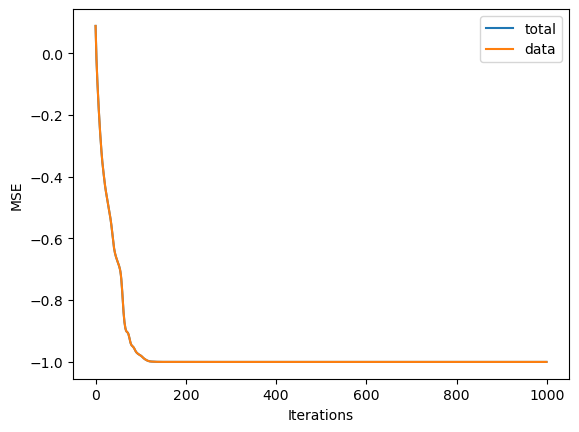

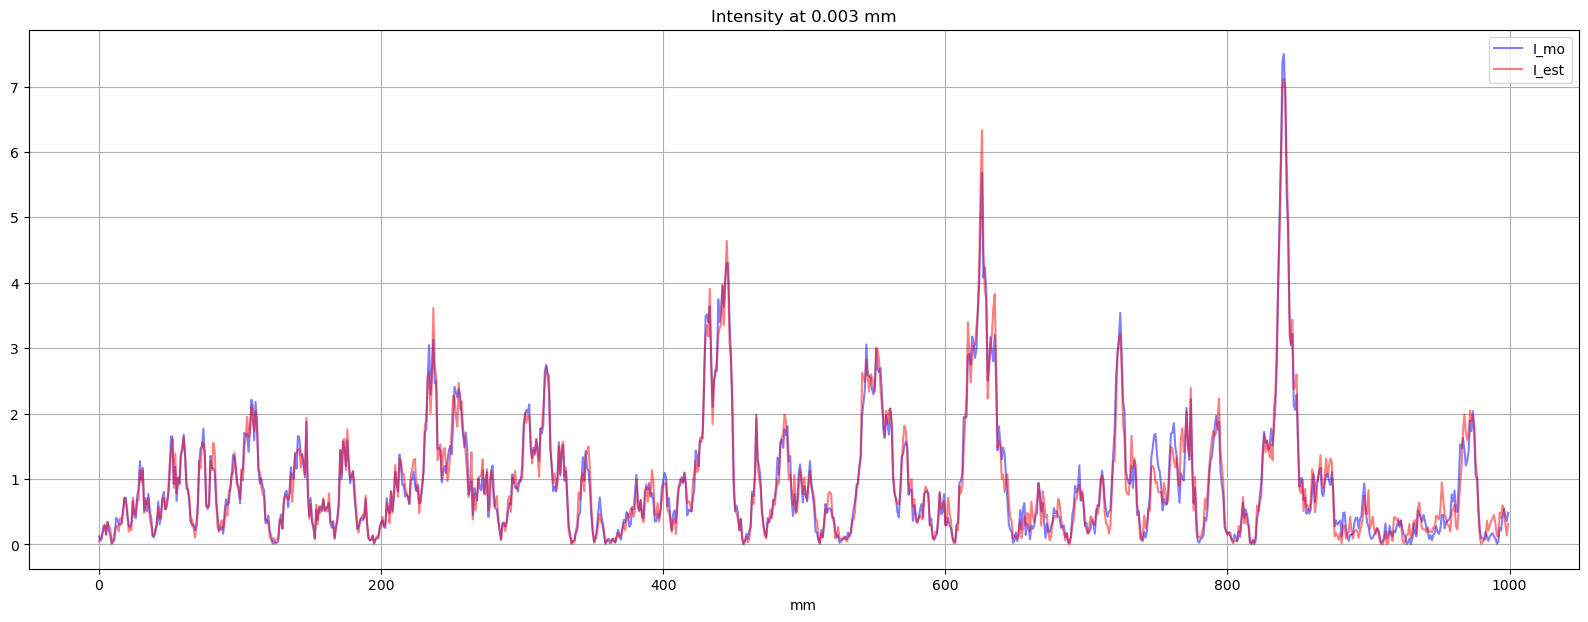

In [46]:
plt.plot(np.log10(losses), label='total')
plt.plot(np.log10(losses_data), label='data')

plt.ylabel('MSE')
plt.xlabel('Iterations')
plt.legend()
plt.show()

fig, axs = plt.subplots(1, figsize=(20, 7))
axs.plot(I_mo[1012:2012], 'b', alpha=0.5, label='I_mo')
axs.plot(y.detach()[1012:2012], 'r', alpha=0.5, label='I_est')

plt.title(f'Intensity at {dist} mm')
plt.xlabel('mm')
plt.legend()
plt.grid()
plt.show()

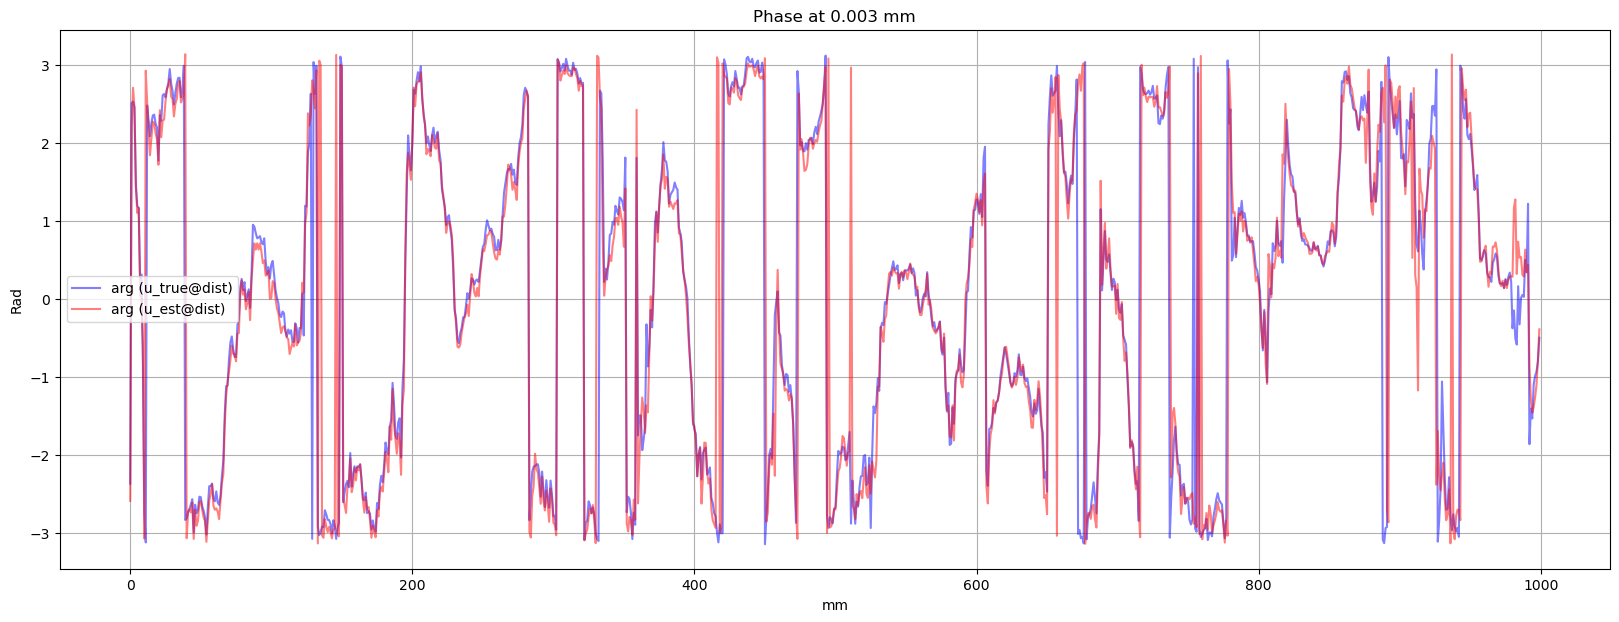

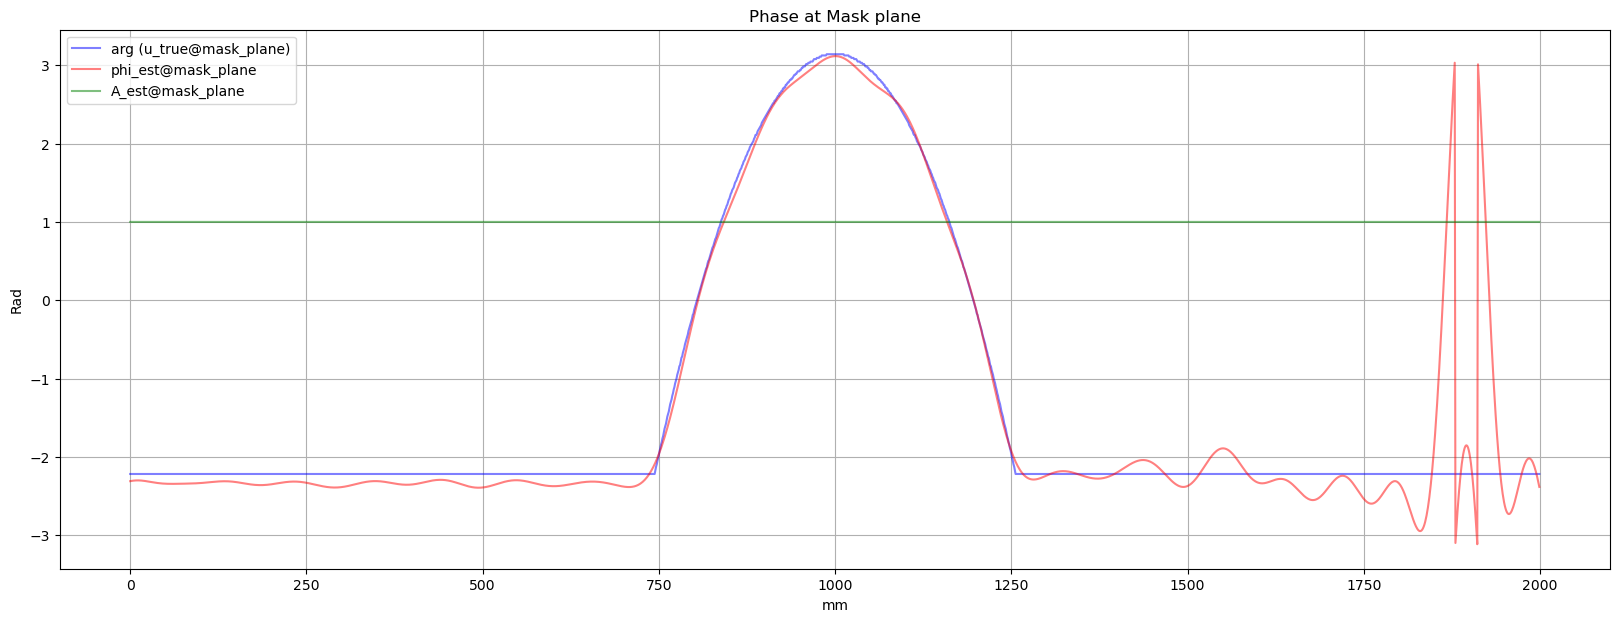

In [55]:
fig, axs = plt.subplots(1, figsize=(20, 7))

axs.plot((torch.angle(propagate_1d(torch.matmul(T_d, conv_field), dist, wl, dx))**1)[1012:2012], 'b', alpha=0.5, label='arg (u_true@dist)')
axs.plot(1*(torch.angle(propagate_1d(torch.matmul(T_d, torch.exp(1j*torch.tensor(4.8))*u_est.detach()), dist, wl, dx))**1)[1012:2012], 'r', alpha=0.5, label='arg (u_est@dist)')

plt.title(f'Phase at {dist} mm')
plt.ylabel('Rad')
plt.xlabel('mm')
plt.legend()
plt.grid()
plt.show()

fig, axs = plt.subplots(1, figsize=(20, 7))

axs.plot(torch.angle(conv_field)[512:2512], 'b', alpha=0.5, label='arg (u_true@mask_plane)')
# axs.plot(1*(torch.matmul(L.tensor, coeff_est).squeeze().detach())[512:2512], 'r', alpha=0.5, label='phi_est@mask_plane')
axs.plot(1*(torch.angle(torch.exp(1j*torch.tensor(4.8))*u_est.detach()))[512:2512], 'r', alpha=0.5, label='phi_est@mask_plane')
axs.plot(A_est.detach()[512:2512], 'g', alpha=0.5, label='A_est@mask_plane')

plt.title(f'Phase at Mask plane')
plt.ylabel('Rad')
plt.xlabel('mm')
plt.legend()
plt.grid()
plt.show()

# FLOW: Given I_r and I_0, find u_est

In [64]:
# set system params

# Grid and propagation parameters setup
wl = 640e-9 # meters
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 2000 # nx == ny

padding = 512
dist = 3e-3 # distance bw phase mask and image plane 

# create phase mask: 
# diagonal phase-only transmission matrix

side_length = 10e-6
tile_size = int(side_length/dx)
RI_pm = 1.46
height = wl/(2*(RI_pm - n_0))#695e-9 # \pi = 2\pi /wl * (RI_pm - 1)*h => h = wl/(2*(RI_pm - n_0))
prob = 0.5

nx_tiles = nx//tile_size
samples_mask = np.random.uniform(size=nx_tiles) > prob

# strucutres size-distance away from boundary
samples_mask[0] = 0.
samples_mask[-1] = 0.

# 1d propagator

def propagate_1d(field, dist, wl, dx):

        k0 = 2 * torch.pi / wl
        Nx = field.shape[0]

        kx = torch.fft.fftfreq(Nx, dx) * 2 * torch.pi
        kz = torch.sqrt(k0**2 - kx**2)

        field_fft = torch.fft.fft(field)
        transfer_function = torch.exp(1j*kz*dist)
        out_field = torch.fft.ifft(field_fft * transfer_function)
        
        return out_field

def total_variation_loss(img, l=2):
     return (torch.abs(img[1:] - img[:-1])**l).sum()/img.size()[0]

h_map_pm = height*np.repeat(samples_mask, tile_size, axis=0)
h_map_pm = np.pad(h_map_pm, padding, 'edge')

opd_pm = h_map_pm*RI_pm + (h_map_pm.max() - h_map_pm)*n_0
t_diag = np.exp(1j*(2*np.pi/wl)*opd_pm) # no negative sign

T_d = torch.diag(torch.from_numpy(t_diag))
T_d.shape, T_d.type, T_d[:4, :4]

u_ir = propagate_1d(torch.matmul(T_d, torch.ones(T_d.shape[1], dtype=torch.complex128)), 
                    dist, wl, dx)


x_cords = torch.arange(-1*(nx/2 + padding) , nx/2 + padding)*dx
z_f = 15e-3 # m

phi_conv = torch.sqrt(z_f**2 + x_cords**2)

phi_conv[:1256] = phi_conv[1256]
phi_conv[1768:] = phi_conv[1768]

conv_field = torch.exp(-1j*(2*torch.pi/wl)*phi_conv).type(torch.complex128)

u_io = propagate_1d(torch.matmul(T_d, conv_field), dist, wl, dx)

# optimization6: \min {phi_est} |I0(r + \grad(phi_est)) - I1|^2 + \gamma(TV phi_est) 

* does not work at all

In [65]:
# optimization || |FMFT Ae{i.phi}|^2 - |u|^2 || + \beta|TV phi|

# dist = 5e-3
# z_f = 15e-3 # m
iter = 5000
learning_rate = 1e-2
gamma = 1e2

I_mo = torch.abs(u_io)**2
I_mr = torch.abs(u_ir)**2

# A_est = torch.ones_like(I_mo)
phi_est = 6*torch.rand_like(I_mo) - 3
# phi_est = torch.ones_like(I_mo)
phi_est.requires_grad = True

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam([phi_est], lr=learning_rate)

losses = []
losses_data = []
# losses_A = []
losses_phi_reg = []

# init grid
x = torch.linspace(-1, 1, I_mo.shape[0], dtype=torch.float64)
X_grid, Y_grid = torch.meshgrid((x, torch.tensor([1.], dtype=torch.float64))) # 1d data but grid sample works for 2d
grad_optr = torch.tensor([-1., 1. , 0.], dtype=torch.double)

for i in range(iter):
    
    grad_phi =  F.conv1d(phi_est.unsqueeze(0).unsqueeze(0), grad_optr.unsqueeze(0).unsqueeze(0), padding='same').squeeze()
    X_grid_warped = X_grid - grad_phi.unsqueeze(1)
    X_grid_clamped = X_grid_warped.clamp(-1, 1)
    grid = torch.hstack((Y_grid.unsqueeze(-1), X_grid_clamped.unsqueeze(-1))).permute(0, 2, 1).unsqueeze(0)  # Shape: (1, N, 1, 2)
    
    I_est = F.grid_sample(I_mr.unsqueeze(0).unsqueeze(0).unsqueeze(-1), grid, align_corners=True, mode='bilinear').squeeze()
    
    loss1 = loss_fn(I_est, I_mo)
    loss2 = gamma*total_variation_loss(phi_est, l=2)

    loss = loss1 + loss2
     
    print(i, loss.item())
    
    losses.append(loss.item())
    losses_data.append(loss1.item())
    losses_phi_reg.append(loss2.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

0 620.1313166955752
1 613.7769982862716
2 607.4431412648853
3 601.2082857038882
4 595.0129662826414
5 588.9372220205099
6 582.8903207641608
7 576.9669547470281
8 571.094801739487
9 565.3508134201616
10 559.6105728188805
11 553.916908992444
12 548.313115470669
13 542.7427985043544
14 537.2870291375415
15 531.8592541312332
16 526.431245058707
17 521.14665348458
18 515.8627411370686
19 510.613682351996
20 505.42375191718025
21 500.28756148461144
22 495.22856436844415
23 490.20680074278545
24 485.27621987958054
25 480.36335608809253
26 475.5596879921783
27 470.745711418501
28 466.02908145653635
29 461.31418571125187
30 456.6829576921612
31 452.11677786677245
32 447.58930761058537
33 443.07009918931254
34 438.6609468877534
35 434.25144499598235
36 429.90621478466954
37 425.65918765143044
38 421.41652865462925
39 417.2127140096751
40 413.0789119197856
41 409.00372210485693
42 404.96551308034014
43 400.99025322880107
44 397.02209956120424
45 393.1380249648021
46 389.2967006224907
47 385.48854

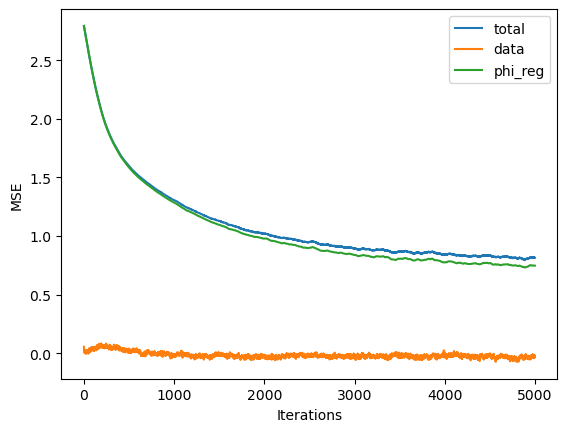

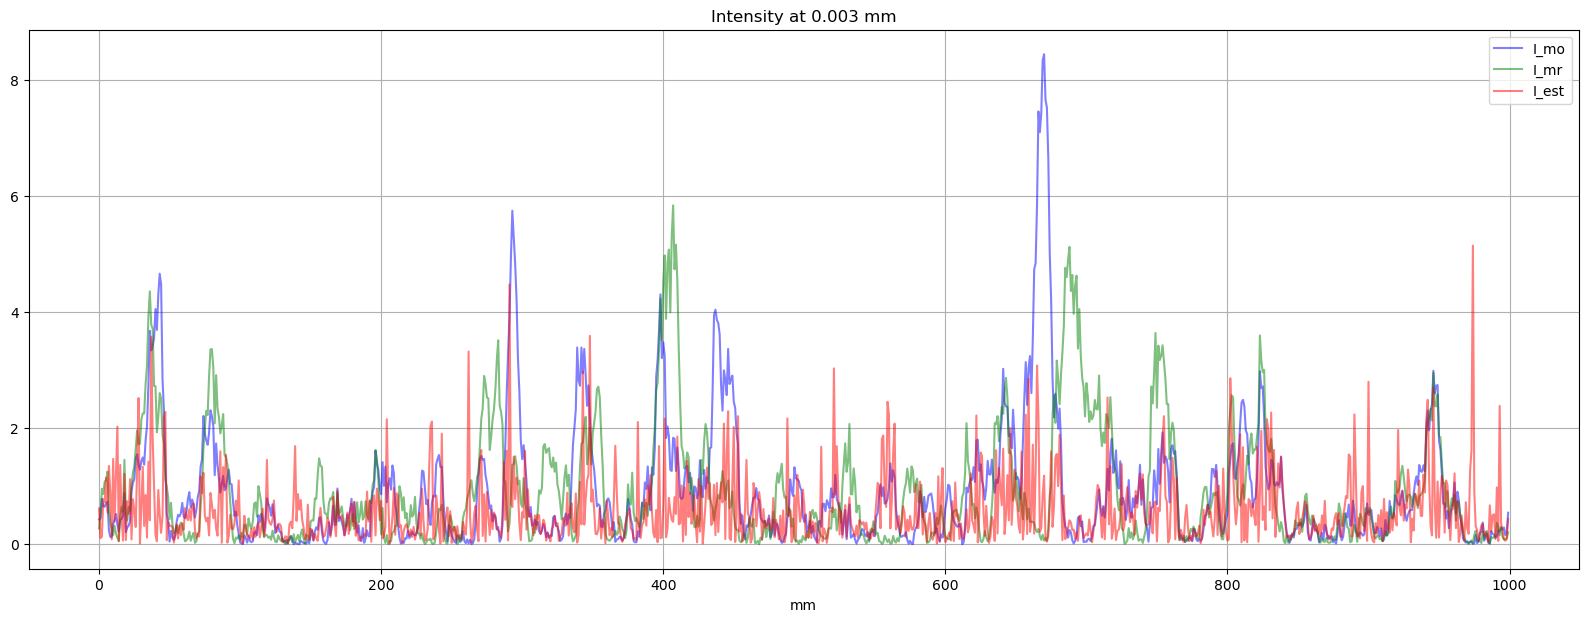

In [66]:
plt.plot(np.log10(losses), label='total')
plt.plot(np.log10(losses_data), label='data')
plt.plot(np.log10(losses_phi_reg), label='phi_reg')

plt.ylabel('MSE')
plt.xlabel('Iterations')
plt.legend()
plt.show()

fig, axs = plt.subplots(1, figsize=(20, 7))
axs.plot(I_mo[1012:2012], 'b', alpha=0.5, label='I_mo')
axs.plot(I_mr[1012:2012], 'g', alpha=0.5, label='I_mr')
axs.plot(I_est.detach()[1012:2012], 'r', alpha=0.5, label='I_est')

plt.title(f'Intensity at {dist} mm')
plt.xlabel('mm')
plt.legend()
plt.grid()
plt.show()

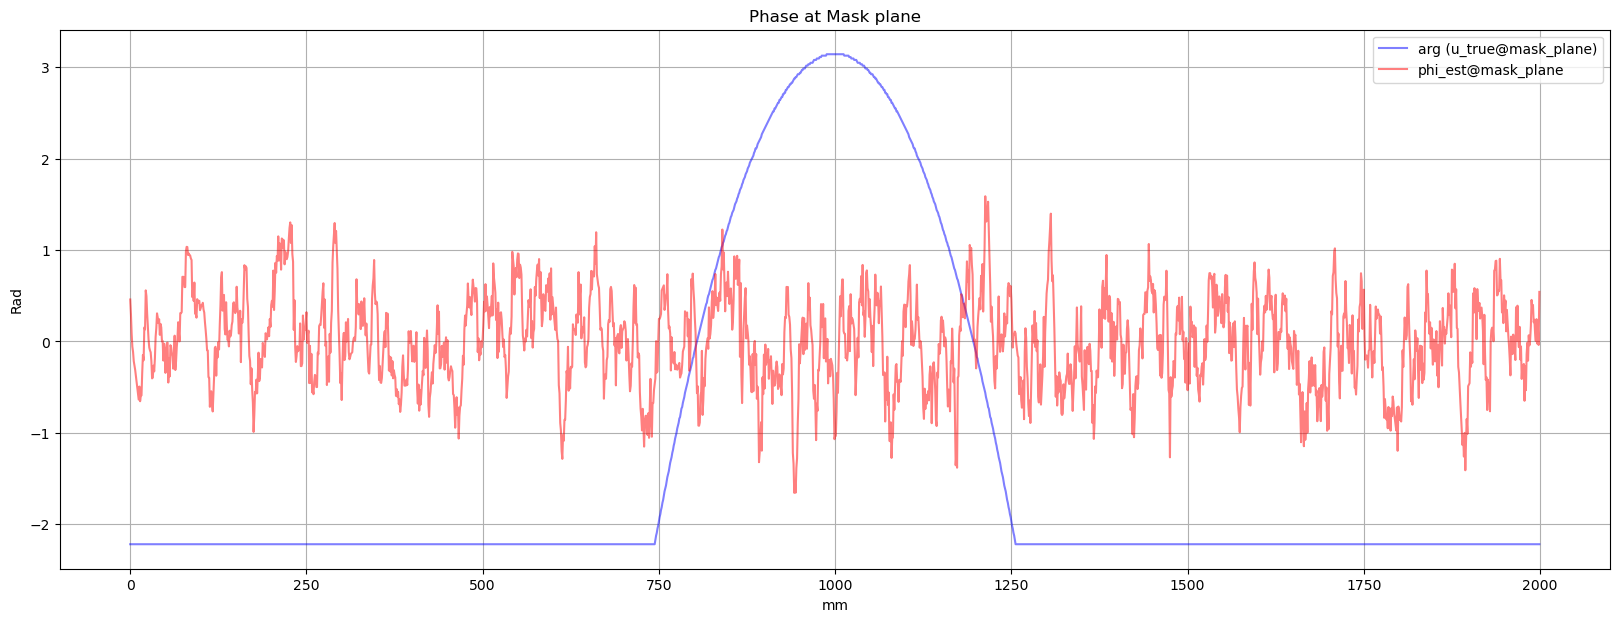

In [67]:
fig, axs = plt.subplots(1, figsize=(20, 7))

axs.plot(torch.angle(conv_field)[512:2512], 'b', alpha=0.5, label='arg (u_true@mask_plane)')
# axs.plot(1*(torch.matmul(L.tensor, coeff_est).squeeze().detach())[512:2512], 'r', alpha=0.5, label='phi_est@mask_plane')
axs.plot((phi_est.detach())[512:2512], 'r', alpha=0.5, label='phi_est@mask_plane')
# axs.plot(A_est.detach()[512:2512], 'g', alpha=0.5, label='A_est@mask_plane')

plt.title(f'Phase at Mask plane')
plt.ylabel('Rad')
plt.xlabel('mm')
plt.legend()
plt.grid()
plt.show()

# optimization7: \min {coeff_L} |I0(r + \grad(\sum coeff_L* L)) - I1|^2 

* works for short distance like 0.5 mm when I0 and I1 very similar
    * works with 20 - 25 polynomials
* when I0 and Ir look different like at 3 mm, estimated phase can be anything 

In [89]:
# optimization || |FMFT Ae{i.phi}|^2 - |u|^2 || + \beta|TV phi|

# dist = 5e-3
# z_f = 15e-3 # m
iter = 5000
learning_rate = 1e-2

num_pol = 20
gamma = 1

I_mo = torch.abs(u_io)**2
I_mr = torch.abs(u_ir)**2

# A_est = torch.ones_like(I_mo)
# phi_est = 6*torch.rand_like(I_mo) - 3
# phi_est = torch.ones_like(I_mo)
# phi_est.requires_grad = True

losses = []
losses_data = []
# losses_A = []
# losses_phi_reg = []

x = torch.linspace(-1, 1, I_mo.shape[0])
L = Legendre(x.unsqueeze(1), num_pol)

coeff_est = torch.randn(num_pol+1, 1)
coeff_est.requires_grad = True

loss_fn = torch.nn.MSELoss()
# loss_fn = torch.nn.L1Loss()
optimizer = torch.optim.Adam([coeff_est], lr=learning_rate)

# init grid
x = torch.linspace(-1, 1, I_mo.shape[0], dtype=torch.float64)
X_grid, Y_grid = torch.meshgrid((x, torch.tensor([1.], dtype=torch.float64))) # 1d data but grid sample works for 2d
grad_optr = torch.tensor([-1., 1. , 0.], dtype=torch.double)

for i in range(iter):
    phi_est = torch.matmul(L.tensor, coeff_est).squeeze().double()
    grad_phi =  F.conv1d(phi_est.unsqueeze(0).unsqueeze(0), grad_optr.unsqueeze(0).unsqueeze(0), padding='same').squeeze()
    X_grid_warped = X_grid - grad_phi.unsqueeze(1)
    X_grid_clamped = X_grid_warped.clamp(-1, 1)
    grid = torch.hstack((Y_grid.unsqueeze(-1), X_grid_clamped.unsqueeze(-1))).permute(0, 2, 1).unsqueeze(0)  # Shape: (1, N, 1, 2)
    
    I_est = F.grid_sample(I_mr.unsqueeze(0).unsqueeze(0).unsqueeze(-1), grid, align_corners=True, mode='bilinear').squeeze()
    
    loss1 = loss_fn(I_est, I_mo)
    # loss2 = gamma*total_variation_loss(phi_est, l=2)

    loss = loss1
     
    print(i, loss.item())
    
    losses.append(loss.item())
    losses_data.append(loss1.item())
    # losses_phi_reg.append(loss2.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 0.9619857379266026
1 0.9534059496850505
2 0.9498341217174499
3 0.9448617293428051
4 0.9366453621476174
5 0.9326051732451575
6 0.9274539601939742
7 0.9216962408584655
8 0.9168385504691331
9 0.9117205037501255
10 0.9068311008780956
11 0.9021224982895996
12 0.8971728253582087
13 0.8925692695968113
14 0.8874249106898772
15 0.882085813648748
16 0.8766550810125996
17 0.8697182956277782
18 0.864220288883007
19 0.8589337005215382
20 0.8550451814974334
21 0.8492195030723286
22 0.8453122008456144
23 0.841122154759435
24 0.8356365782563849
25 0.8312213840503485
26 0.8258476206785312
27 0.8203499466890287
28 0.8164301946408604
29 0.812153638432556
30 0.8089070671655049
31 0.8050335559387106
32 0.8007115955730381
33 0.7960872860113916
34 0.7927269289001213
35 0.7877986012207634
36 0.7827902501409135
37 0.7792128613186883
38 0.7753076291711068
39 0.771965035380543
40 0.7676503093176271
41 0.7633910563448135
42 0.7597680608584645
43 0.7560361996377201
44 0.752444379232551
45 0.7483496261533358
46 0

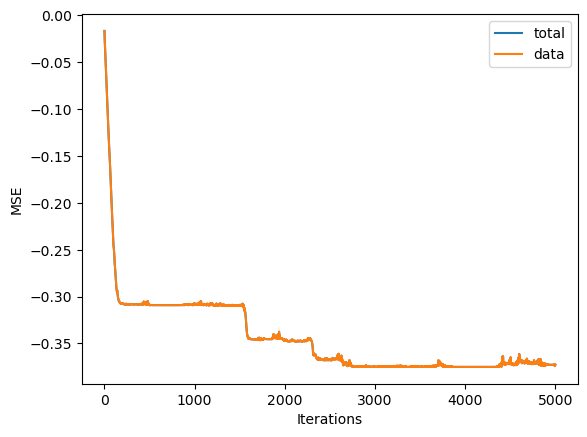

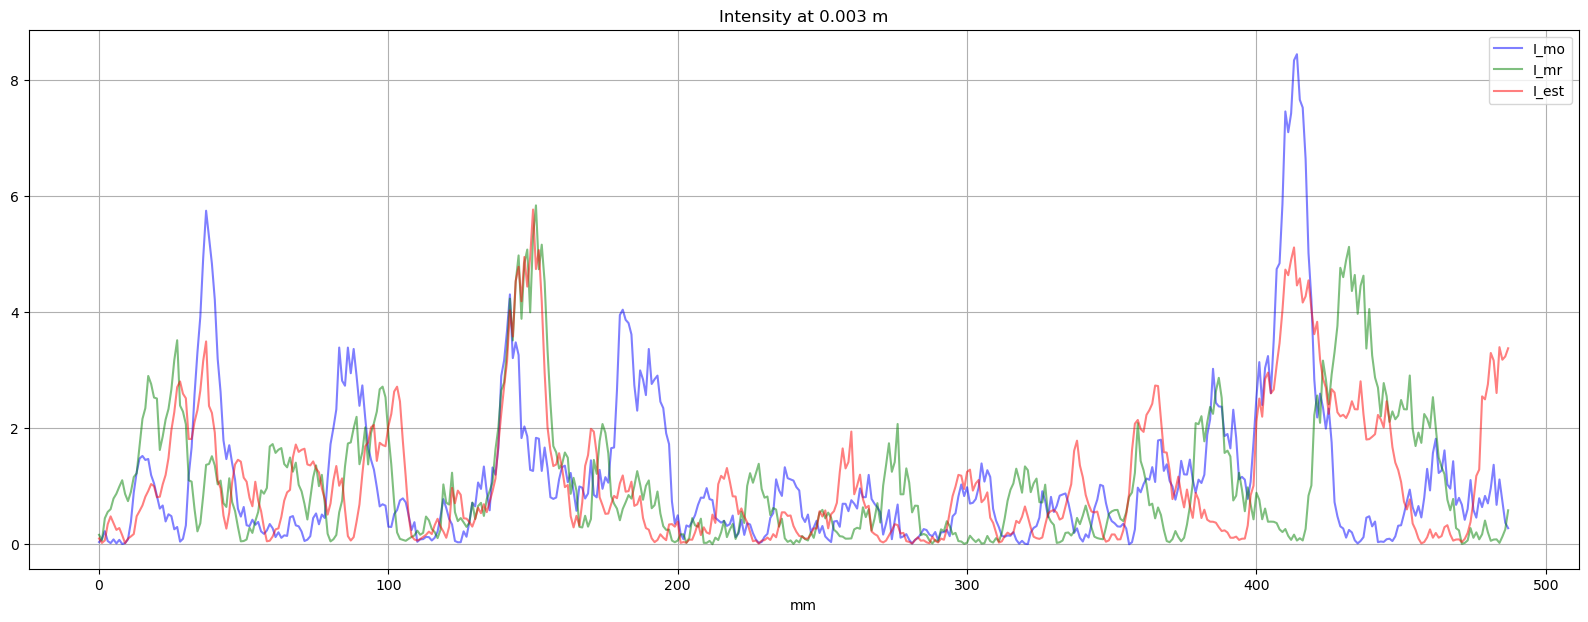

In [90]:
plt.plot(np.log10(losses), label='total')
plt.plot(np.log10(losses_data), label='data')
# plt.plot(np.log10(losses_phi_reg), label='phi_reg')

plt.ylabel('MSE')
plt.xlabel('Iterations')
plt.legend()
plt.show()

fig, axs = plt.subplots(1, figsize=(20, 7))
axs.plot(I_mo[1012+256:-256+2012], 'b', alpha=0.5, label='I_mo')
axs.plot(I_mr[1012+256:-256+2012], 'g', alpha=0.5, label='I_mr')
axs.plot(I_est.detach()[1012+256:-256+2012], 'r', alpha=0.5, label='I_est')

plt.title(f'Intensity at {dist} m')
plt.xlabel('mm')
plt.legend()
plt.grid()
plt.show()

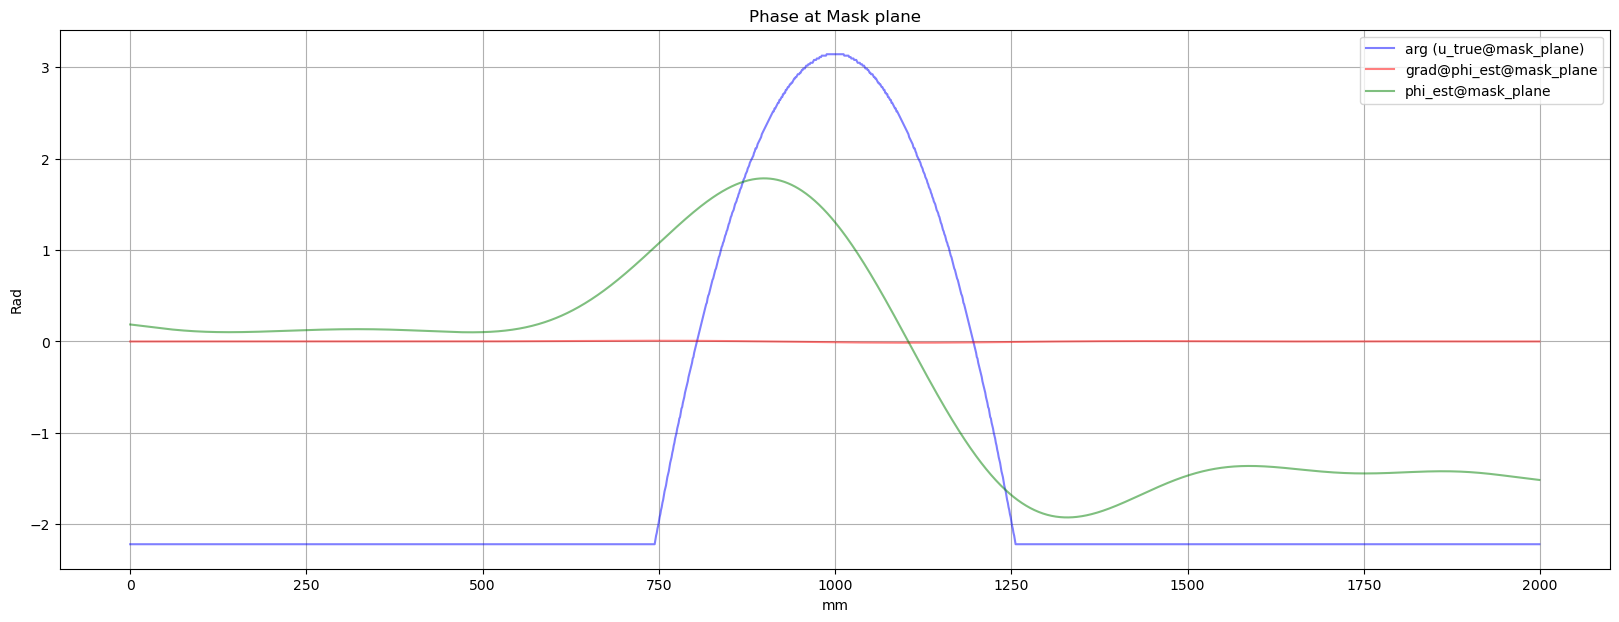

In [91]:
fig, axs = plt.subplots(1, figsize=(20, 7))

axs.plot(torch.angle(conv_field)[512:2512], 'b', alpha=0.5, label='arg (u_true@mask_plane)')
# axs.plot(1*(torch.matmul(L.tensor, coeff_est).squeeze().detach())[512:2512], 'r', alpha=0.5, label='phi_est@mask_plane')
axs.plot((grad_phi.detach())[512:2512], 'r', alpha=0.5, label='grad@phi_est@mask_plane')
axs.plot((phi_est.detach())[512:2512], 'g', alpha=0.5, label='phi_est@mask_plane')
# axs.plot(A_est.detach()[512:2512], 'g', alpha=0.5, label='A_est@mask_plane')

plt.title(f'Phase at Mask plane')
plt.ylabel('Rad')
plt.xlabel('mm')
plt.legend()
plt.grid()
plt.show()

# Reason why optical flow does not work at larger distances

* The objects phase **directs** the speckle field.
* The resulting object speckle pattern is then intersection of a curved plane with the reference speckle field.
* The speckles observed look more and more different as the distance increases and become difficult to track.

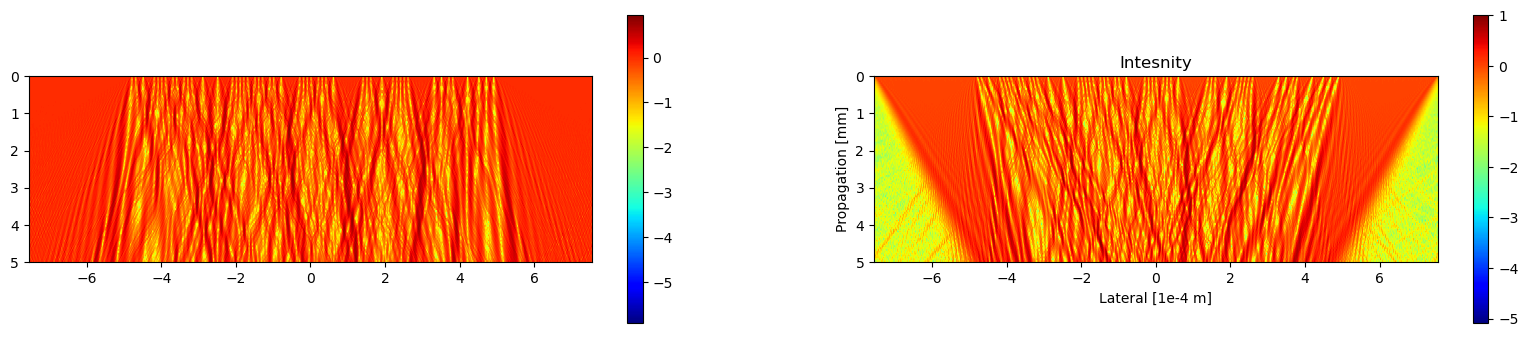

In [101]:
# converging wave
# \phi(x, y) = -k*sqrt(z_f**2 x**2 + y**2)
u_io_z = torch.zeros([101, u_ir.shape[0]], dtype=torch.complex128)
u_io_r = torch.zeros([101, u_ir.shape[0]], dtype=torch.complex128)


x_cords = torch.arange(-1*(nx/2 + padding) , nx/2 + padding)*dx
z_f = 15e-3 # m

phi_conv = torch.sqrt(z_f**2 + x_cords**2)

# phi_conv[:1256] = phi_conv[1256]
# phi_conv[1768:] = phi_conv[1768]

conv_field = torch.exp(-1j*(2*torch.pi/wl)*phi_conv).type(torch.complex128)

for idx, z in enumerate(np.linspace(0, 5, 101)):
    u_io_z[idx] = propagate_1d(torch.matmul(T_d, conv_field), z*1e-3, wl, dx)
    u_io_r[idx] = propagate_1d(T_d.diag(), z*1e-3, wl, dx)
    
fig, axs = plt.subplots(1, 2, figsize=(20, 4))

cm0 = axs[0].imshow(np.log10(torch.abs(u_io_r)**2), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm0, ax=axs[0])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Intensity')

cm1 = axs[1].imshow(np.log10(torch.abs(u_io_z)**2), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm1, ax=axs[1])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Intesnity')

plt.show()

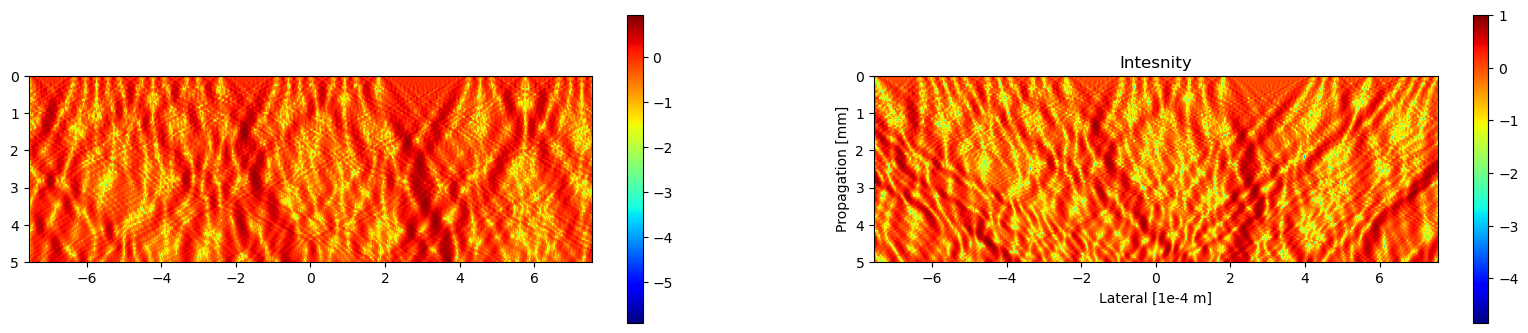

In [106]:
fig, axs = plt.subplots(1, 2, figsize=(20, 4))

cm0 = axs[0].imshow(np.log10(torch.abs(u_io_r[:, 1012:2012])**2), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm0, ax=axs[0])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Intensity')

cm1 = axs[1].imshow(np.log10(torch.abs(u_io_z[:, 1012:2012])**2), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm1, ax=axs[1])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Intesnity')

plt.show()

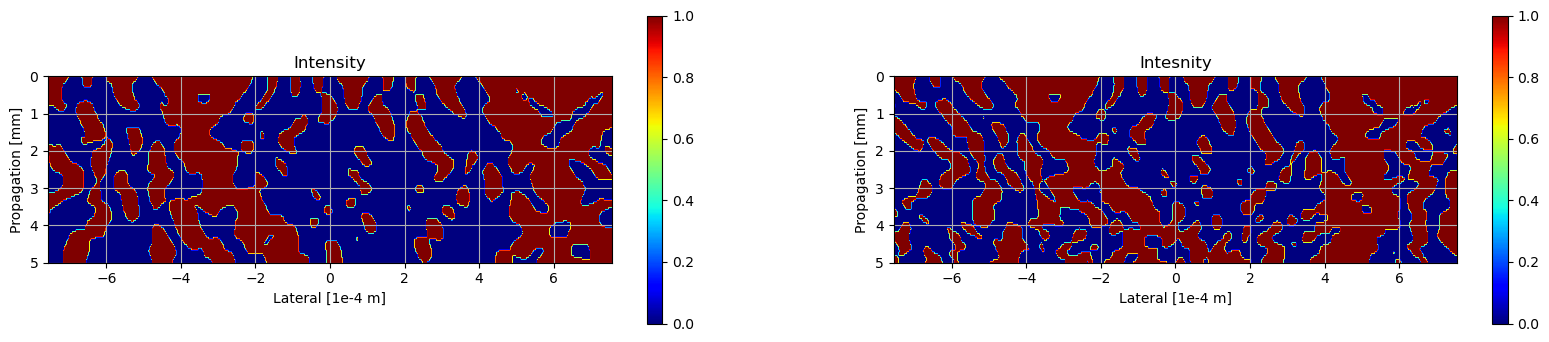

In [124]:
fig, axs = plt.subplots(1, 2, figsize=(20, 4))

cm0 = axs[0].imshow(gaussian_filter(np.log10(torch.abs(u_io_r[:, 1012+256:-256+2012])**2), 2)>-0.1, cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm0, ax=axs[0])
axs[0].set_ylabel('Propagation [mm]')
axs[0].set_xlabel('Lateral [1e-4 m]')
axs[0].set_title('Intensity')
axs[0].grid()

cm1 = axs[1].imshow(gaussian_filter(np.log10(torch.abs(u_io_z[:, 1012+256:-256+2012])**2), 2)>-0.1, cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm1, ax=axs[1])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Intesnity')
axs[1].grid()

plt.show()

In [461]:
# add noise in measurements: simulated ground truth
# why peak at dist?
# cosines with harmonics
# 3 to 5 base cells
# large curvature
